# 准备

LLM：作为 chat 和 答案生成 的大脑，这里使用了 Deepseek API

embedding model: 用来生成嵌入向量，这里使用了 Ollama + bge-m3:latest

安装 doris，详见 Apache Doris 官网 https://doris.apache.org/zh-CN/docs/4.x/install/preparation/env-checking

建库+建表

```
CREATE DATABASE doris_rag_test_db;

USE doris_rag_test_db;

CREATE TABLE `doris_rag_demo` (
  `id` int NULL,
  `content` text NULL,
  `embedding` array<float> NOT NULL,
  INDEX idx_embedding (`embedding`) USING ANN PROPERTIES("dim" = "1024", "ef_construction" = "40", "index_type" = "hnsw", "max_degree" = "32", "metric_type" = "inner_product")
) ENGINE=OLAP
DUPLICATE KEY(`id`)
DISTRIBUTED BY HASH(`id`) BUCKETS 1
PROPERTIES (
"replication_allocation" = "tag.location.default: 1"
); 
```

# 演示用的文档

In [90]:
text = '''
Apache Doris 简介
Apache Doris 是一款基于 MPP 架构的高性能、实时分析型数据库。它以高效、简单和统一的特性著称，能够在亚秒级的时间内返回海量数据的查询结果。Doris 既能支持高并发的点查询场景，也能支持高吞吐的复杂分析场景。

基于这些优势，Apache Doris 非常适合用于报表分析、即席查询、统一数仓构建、数据湖联邦查询加速等场景。用户可以基于 Doris 构建大屏看板、用户行为分析、AB 实验平台、日志检索分析、用户画像分析、订单分析等应用。

发展历程
Apache Doris 最初是百度广告报表业务的 Palo 项目。2017 年正式对外开源，2018 年 7 月由百度捐赠给 Apache 基金会进行孵化。在 Apache 导师的指导下，由孵化器项目管理委员会成员进行孵化和运营。2022 年 6 月，Apache Doris 成功从 Apache 孵化器毕业，正式成为 Apache 顶级项目（Top-Level Project，TLP）。

目前，Apache Doris 社区已经聚集了来自不同行业数百家企业的 700 余位贡献者，并且每月活跃贡献者人数超过 120 位。

应用现状
Apache Doris 在中国乃至全球范围内拥有广泛的用户群体。截至目前，Apache Doris 已经在全球超过 5000 家中大型企业的生产环境中得到应用。在中国市值或估值排行前 50 的互联网公司中，有超过 80% 长期使用 Apache Doris，包括百度、美团、小米、京东、字节跳动、阿里巴巴、腾讯、网易、快手、微博等。同时，在金融、消费、电信、工业制造、能源、医疗、政务等传统行业也有着丰富的应用。

在中国，几乎所有的云厂商，如阿里云、华为云、天翼云、腾讯云、百度云、火山引擎等，都在提供托管的 Apache Doris 云服务。

使用场景
数据源经过各种数据集成和加工处理后，通常会进入实时数据仓库 Doris 和离线湖仓（如 Hive、Iceberg 和 Hudi），广泛应用于 OLAP 分析场景，如下图所示：

Apache Doris 的使用场景

Apache Doris 主要应用于以下场景：

实时数据分析：

实时报表与实时决策： 为企业内外部提供实时更新的报表和仪表盘，支持自动化流程中的实时决策需求。

交互式探索分析： 提供多维数据分析能力，支持对数据进行快速的商业智能分析和即席查询（Ad Hoc），帮助用户在复杂数据中快速发现洞察。

用户行为与画像分析： 分析用户参与、留存、转化等行为，支持人群洞察和人群圈选等画像分析场景。

湖仓融合分析：

湖仓查询加速： 通过高效的查询引擎加速湖仓数据的查询。

多源联邦分析： 支持跨多个数据源的联邦查询，简化架构并消除数据孤岛。

实时数据处理： 结合实时数据流和批量数据的处理能力，满足高并发和低延迟的复杂业务需求。

半结构化数据分析：

日志与事件分析： 对分布式系统中的日志和事件数据进行实时或批量分析，帮助定位问题和优化性能。
整体架构
Apache Doris 采用 MySQL 协议，高度兼容 MySQL 语法，支持标准 SQL。用户可以通过各类客户端工具访问 Apache Doris，并支持与 BI 工具无缝集成。在部署 Apache Doris 时，可以根据硬件环境与业务需求选择存算一体架构或存算分离架构。

存算一体架构
Apache Doris 存算一体架构精简且易于维护。它包含以下两种类型的进程：

Frontend (FE)： 主要负责接收用户请求、查询解析和规划、元数据管理以及节点管理。

Backend (BE)： 主要负责数据存储和查询计划的执行。数据会被切分成数据分片（Shard），在 BE 中以多副本方式存储。

MPP 数据库整体架构和技术特点

在生产环境中，可以部署多个 FE 节点以实现容灾备份。每个 FE 节点都会维护完整的元数据副本。FE 节点分为以下三种角色：

角色	功能
Master	FE Master 节点负责元数据的读写。当 Master 节点的元数据发生变更后，会通过 BDB JE 协议同步给 Follower 或 Observer 节点。
Follower	Follower 节点负责读取元数据。当 Master 节点发生故障时，可以选取一个 Follower 节点作为新的 Master 节点。
Observer	Observer 节点负责读取元数据，主要目的是增加集群的查询并发能力。Observer 节点不参与集群的选主过程。
FE 和 BE 进程都可以横向扩展。单个集群可以支持数百台机器和数十 PB 的存储容量。FE 和 BE 进程通过一致性协议来保证服务的高可用性和数据的高可靠性。存算一体架构高度集成，大幅降低了分布式系统的运维成本。

存算分离架构
从 3.0 版本开始，可以选择存算分离部署架构。Apache Doris 存算分离版使用统一的共享存储层作为数据存储空间。存储和计算分离后，用户可以独立扩展存储容量和计算资源，从而实现最佳性能和成本效益。存算分离架构分为以下三层：

元数据层： 负责请求规划、查询解析以及元数据的存储和管理。

计算层： 由多个计算组组成。每个计算组可以作为一个独立的租户承担业务计算。每个计算组包含多个无状态的 BE 节点，可以随时弹性伸缩 BE 节点。

存储层： 可以使用 S3、HDFS、OSS、COS、OBS、Minio、Ceph 等共享存储来存放 Doris 的数据文件，包括 Segment 文件和反向索引文件等。

存算分离整体架构和技术特点

Apache Doris 的核心特性
高可用： Apache Doris 的元数据和数据均采用多副本存储，并通过 Quorum 协议同步数据日志。当大多数副本完成写入后，即认为数据写入成功，从而确保即使少数节点发生故障，集群仍能保持可用性。Apache Doris 支持同城和异地容灾，能够实现双集群主备模式。当部分节点发生异常时，集群可以自动隔离故障节点，避免影响整体集群的可用性。

高兼容： Apache Doris 高度兼容 MySQL 协议，支持标准 SQL 语法，涵盖绝大部分 MySQL 和 Hive 函数。通过这种高兼容性，用户可以无缝迁移和集成现有的应用和工具。Apache Doris 支持 MySQL 生态，用户可以通过 MySQL 客户端工具连接 Doris，使得操作和维护更加便捷。同时，可以使用 MySQL 协议对 BI 报表工具与数据传输工具进行兼容适配，确保数据分析和数据传输过程中的高效性和稳定性。

实时数仓： 基于 Apache Doris 可以构建实时数据仓库服务。Apache Doris 提供了秒级数据入库能力，上游在线联机事务库中的增量变更可以秒级捕获到 Doris 中。依靠向量化引擎、MPP 架构及 Pipeline 执行引擎等加速手段，可以提供亚秒级数据查询能力，从而构建高性能、低延迟的实时数仓平台。

湖仓一体： Apache Doris 可以基于外部数据源（如数据湖或关系型数据库）构建湖仓一体架构，从而解决数据在数据湖和数据仓库之间无缝集成和自由流动的问题，帮助用户直接利用数据仓库的能力来解决数据湖中的数据分析问题，同时充分利用数据湖的数据管理能力来提升数据的价值。

灵活建模： Apache Doris 提供多种建模方式，如宽表模型、预聚合模型、星型/雪花模型等。数据导入时，可以通过 Flink、Spark 等计算引擎将数据打平成宽表写入到 Doris 中，也可以将数据直接导入到 Doris 中，通过视图、物化视图或实时多表关联等方式进行数据的建模操作。

技术特点
Doris 提供了高效的 SQL 接口，并完全兼容 MySQL 协议。其查询引擎基于 MPP（大规模并行处理）架构，能够高效执行复杂的分析查询，并实现低延迟的实时查询。通过列式存储技术对数据进行编码与压缩，显著优化了查询性能和存储压缩比。

使用接口
Apache Doris 采用 MySQL 协议，高度兼容 MySQL 语法，支持标准 SQL。用户可以通过各类客户端工具访问 Apache Doris，并支持与 BI 工具无缝集成。Apache Doris 当前支持多种主流的 BI 产品，包括 Smartbi、DataEase、FineBI、Tableau、Power BI、Apache Superset 等。只要支持 MySQL 协议的 BI 工具，Apache Doris 就可以作为数据源提供查询支持。

存储引擎
在存储引擎方面，Apache Doris 采用列式存储，按列进行数据的编码、压缩和读取，能够实现极高的压缩比，同时减少大量非相关数据的扫描，从而更有效地利用 IO 和 CPU 资源。

Apache Doris 也支持多种索引结构，以减少数据的扫描：

Sorted Compound Key Index： 最多可以指定三个列组成复合排序键。通过该索引，能够有效进行数据裁剪，从而更好地支持高并发的报表场景。

Min/Max Index： 有效过滤数值类型的等值和范围查询。

BloomFilter Index： 对高基数列的等值过滤裁剪非常有效。

Inverted Index： 能够对任意字段实现快速检索。

在存储模型方面，Apache Doris 支持多种存储模型，针对不同的场景做了针对性的优化：

明细模型（Duplicate Key Model）： 适用于事实表的明细数据存储。

主键模型（Unique Key Model）： 保证 Key 的唯一性，相同 Key 的数据会被覆盖，从而实现行级别数据更新。

聚合模型（Aggregate Key Model）： 相同 Key 的 Value 列会被合并，通过提前聚合大幅提升性能。

Apache Doris 也支持强一致的单表物化视图和异步刷新的多表物化视图。单表物化视图在系统中自动刷新和维护，无需用户手动选择。多表物化视图可以借助集群内的调度或集群外的调度工具定时刷新，从而降低数据建模的复杂性。

查询引擎
Apache Doris 采用大规模并行处理（MPP）架构，支持节点间和节点内并行执行，以及多个大型表的分布式 Shuffle Join，从而更好地应对复杂查询。

查询引擎

Doris 查询引擎是向量化引擎，所有内存结构均按列式布局，可显著减少虚函数调用，提高缓存命中率，并有效利用 SIMD 指令。在宽表聚合场景下，性能是非向量化引擎的 5-10 倍。

Doris 查询引擎是向量化

Doris 采用自适应查询执行（Adaptive Query Execution）技术，根据运行时统计信息动态调整执行计划。例如，通过运行时过滤（Runtime Filter）技术，可以在运行时生成过滤器并将其推送到 Probe 端，并自动将过滤器穿透到 Probe 端最底层的 Scan 节点，从而大幅减少 Probe 端的数据量，加速 Join 性能。Doris 的运行时过滤器支持 In/Min/Max/Bloom Filter。

pip_exec_3

Doris 使用 Pipeline 执行引擎，将查询分解为多个子任务并行执行，充分利用多核 CPU 的能力，同时通过限制查询线程数来解决线程膨胀问题。Pipeline 执行引擎减少数据拷贝和共享，优化排序和聚合操作，从而显著提高查询效率和吞吐量。

在优化器方面，Doris 采用 CBO、RBO 和 HBO 相结合的优化策略。RBO 支持常量折叠、子查询重写和谓词下推等优化，CBO 支持 Join Reorder 等优化，HBO 能够基于历史查询信息推荐最优执行计划。多种优化措施确保 Doris 能够在各类查询中枚举出性能优异的查询计划。
'''

# 离线文档处理
文档切块 (chunking)，采用简单的 overlap 分割方法

In [91]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400, chunk_overlap=10, length_function=len
)
chunks = text_splitter.split_text(text)
chunks

['Apache Doris 简介\nApache Doris 是一款基于 MPP 架构的高性能、实时分析型数据库。它以高效、简单和统一的特性著称，能够在亚秒级的时间内返回海量数据的查询结果。Doris 既能支持高并发的点查询场景，也能支持高吞吐的复杂分析场景。\n\n基于这些优势，Apache Doris 非常适合用于报表分析、即席查询、统一数仓构建、数据湖联邦查询加速等场景。用户可以基于 Doris 构建大屏看板、用户行为分析、AB 实验平台、日志检索分析、用户画像分析、订单分析等应用。',
 '发展历程\nApache Doris 最初是百度广告报表业务的 Palo 项目。2017 年正式对外开源，2018 年 7 月由百度捐赠给 Apache 基金会进行孵化。在 Apache 导师的指导下，由孵化器项目管理委员会成员进行孵化和运营。2022 年 6 月，Apache Doris 成功从 Apache 孵化器毕业，正式成为 Apache 顶级项目（Top-Level Project，TLP）。\n\n目前，Apache Doris 社区已经聚集了来自不同行业数百家企业的 700 余位贡献者，并且每月活跃贡献者人数超过 120 位。',
 '应用现状\nApache Doris 在中国乃至全球范围内拥有广泛的用户群体。截至目前，Apache Doris 已经在全球超过 5000 家中大型企业的生产环境中得到应用。在中国市值或估值排行前 50 的互联网公司中，有超过 80% 长期使用 Apache Doris，包括百度、美团、小米、京东、字节跳动、阿里巴巴、腾讯、网易、快手、微博等。同时，在金融、消费、电信、工业制造、能源、医疗、政务等传统行业也有着丰富的应用。\n\n在中国，几乎所有的云厂商，如阿里云、华为云、天翼云、腾讯云、百度云、火山引擎等，都在提供托管的 Apache Doris 云服务。\n\n使用场景\n数据源经过各种数据集成和加工处理后，通常会进入实时数据仓库 Doris 和离线湖仓（如 Hive、Iceberg 和 Hudi），广泛应用于 OLAP 分析场景，如下图所示：\n\nApache Doris 的使用场景',
 'Apache Doris 主要应用于以下场景：\n\n实时数据分析：\n\n实时报表与实时决策： 为企业内外部提供实时更新的报

构建嵌入 (embedding)

In [ ]:
from langchain_community.embeddings import OllamaEmbeddings
from typing import List, Dict

embeddings = OllamaEmbeddings(model='bge-m3:latest', base_url='http://localhost:11434')

docs: List[Dict] = []
cur_id = 1

for chunk in chunks:
    docs.append(
        {
            "id": cur_id,
            "content": chunk,
        }
    )
    cur_id += 1

contents = [d["content"] for d in docs]
vectors = embeddings.embed_documents(contents)
vectors

导入 doris

In [93]:
import pandas as pd

df = pd.DataFrame(
        [
            {
                "id": d["id"],
                "content": d["content"],
                "embedding": vec,
            }
            for d, vec in zip(docs, vectors)
        ])
df

,id,content,embedding
0,1,Apache Doris 简介\nApache Doris 是一款基于 MPP 架构的高性能...,"[0.6275007128715515, -0.6036409735679626, -1.3..."
1,2,发展历程\nApache Doris 最初是百度广告报表业务的 Palo 项目。2017 年...,"[-0.5296682715415955, -0.6702555418014526, 0.0..."
2,3,应用现状\nApache Doris 在中国乃至全球范围内拥有广泛的用户群体。截至目前，Ap...,"[-0.5523831248283386, 0.212008997797966, -0.89..."
3,4,Apache Doris 主要应用于以下场景：\n\n实时数据分析：\n\n实时报表与实时决...,"[-0.30162328481674194, 0.019777294248342514, -..."
4,5,日志与事件分析： 对分布式系统中的日志和事件数据进行实时或批量分析，帮助定位问题和优化性能。...,"[0.35130780935287476, -1.1097315549850464, -0...."
5,6,在生产环境中，可以部署多个 FE 节点以实现容灾备份。每个 FE 节点都会维护完整的元数据副...,"[-0.1282055526971817, -1.1078968048095703, -1...."
6,7,角色\t功能\nMaster\tFE Master 节点负责元数据的读写。当 Master ...,"[-0.37338078022003174, -1.5073719024658203, -1..."
7,8,存算分离架构\n从 3.0 版本开始，可以选择存算分离部署架构。Apache Doris 存...,"[0.9033090472221375, -0.7893261909484863, -1.1..."
8,9,Apache Doris 的核心特性\n高可用： Apache Doris 的元数据和数据均...,"[-0.21291303634643555, -0.7927544116973877, -0..."
9,10,高兼容： Apache Doris 高度兼容 MySQL 协议，支持标准 SQL 语法，涵盖...,"[-0.013894216157495975, -0.24680668115615845, ..."


In [96]:
from doris_vector_search import DorisVectorClient, AuthOptions, IndexOptions

auth = AuthOptions(
    host='localhost',
    query_port=9030,
    http_port=8030,
    user='root',
    password='',
)

client = DorisVectorClient('doris_rag_test_db', auth_options=auth)

index_options = IndexOptions(index_type="hnsw", metric_type="inner_product")
table = client.create_table(
            'doris_rag_demo',
            df,
            index_options=index_options,
        )

# 在线查询
向量检索

In [97]:
query = 'doris支持哪些存储模型？'

query_vec = embeddings.embed_query(query)

df = (
    table.search(query_vec)
    .limit(5)
    .select(["id", "content"])
    .to_pandas()
)
df

,id,content
0,14,明细模型（Duplicate Key Model）： 适用于事实表的明细数据存储。\n\n主...
1,13,存储引擎\n在存储引擎方面，Apache Doris 采用列式存储，按列进行数据的编码、压缩...
2,11,湖仓一体： Apache Doris 可以基于外部数据源（如数据湖或关系型数据库）构建湖仓一...
3,10,高兼容： Apache Doris 高度兼容 MySQL 协议，支持标准 SQL 语法，涵盖...
4,12,技术特点\nDoris 提供了高效的 SQL 接口，并完全兼容 MySQL 协议。其查询引擎...


答案生成：

In [98]:
ctx = "\n".join(f"{r['content']}" for _, r in df.iterrows())

prompt =  "以下是检索到的 Doris 文档片段：\n\n{}\n\n请根据上述内容回答：{}".format(ctx, query)

prompt

'以下是检索到的 Doris 文档片段：\n\n明细模型（Duplicate Key Model）： 适用于事实表的明细数据存储。\n\n主键模型（Unique Key Model）： 保证 Key 的唯一性，相同 Key 的数据会被覆盖，从而实现行级别数据更新。\n\n聚合模型（Aggregate Key Model）： 相同 Key 的 Value 列会被合并，通过提前聚合大幅提升性能。\n\nApache Doris 也支持强一致的单表物化视图和异步刷新的多表物化视图。单表物化视图在系统中自动刷新和维护，无需用户手动选择。多表物化视图可以借助集群内的调度或集群外的调度工具定时刷新，从而降低数据建模的复杂性。\n\n查询引擎\nApache Doris 采用大规模并行处理（MPP）架构，支持节点间和节点内并行执行，以及多个大型表的分布式 Shuffle Join，从而更好地应对复杂查询。\n\n查询引擎\n存储引擎\n在存储引擎方面，Apache Doris 采用列式存储，按列进行数据的编码、压缩和读取，能够实现极高的压缩比，同时减少大量非相关数据的扫描，从而更有效地利用 IO 和 CPU 资源。\n\nApache Doris 也支持多种索引结构，以减少数据的扫描：\n\nSorted Compound Key Index： 最多可以指定三个列组成复合排序键。通过该索引，能够有效进行数据裁剪，从而更好地支持高并发的报表场景。\n\nMin/Max Index： 有效过滤数值类型的等值和范围查询。\n\nBloomFilter Index： 对高基数列的等值过滤裁剪非常有效。\n\nInverted Index： 能够对任意字段实现快速检索。\n\n在存储模型方面，Apache Doris 支持多种存储模型，针对不同的场景做了针对性的优化：\n湖仓一体： Apache Doris 可以基于外部数据源（如数据湖或关系型数据库）构建湖仓一体架构，从而解决数据在数据湖和数据仓库之间无缝集成和自由流动的问题，帮助用户直接利用数据仓库的能力来解决数据湖中的数据分析问题，同时充分利用数据湖的数据管理能力来提升数据的价值。\n\n灵活建模： Apache Doris 提供多种建模方式，如宽表模型、预聚合模型、星型/雪花模型等。数据导入时，可以通过 Flink、Spark 等计

In [100]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
            model='deepseek-v3-1-terminus',
            api_key='xxx',
            base_url='https://ark.cn-beijing.volces.com/api/v3',
            temperature=float(1.0))
resp = llm.invoke(prompt)
resp

AIMessage(content='根据提供的 Doris 文档片段，Apache Doris 支持的存储模型可以从两个层面来理解：\n\n### 1. 表数据模型 (Table Data Model)\n\n这是指在创建表时，根据业务场景选择的数据组织方式，核心是三种：\n\n*   **明细模型 (Duplicate Key Model)**： 适用于存储原始的、未经聚合的明细数据，如操作日志、交易流水等。\n*   **聚合模型 (Aggregate Key Model)**： 适用于需要提前聚合汇总数据的场景，相同 Key 的数值列会自动合并（如 SUM、MAX），大幅提升查询性能。\n*   **主键模型 (Unique Key Model)**： 保证主键的唯一性，对相同主键的数据进行覆盖更新，实现了行级别的实时更新能力。\n\n### 2. 架构存储模型 (Architectural Storage Model)\n\n这是指 Doris 在整个数据架构中可以扮演的角色和存储范式：\n\n*   **宽表模型**： 数据导入时，可以通过 ETL 工具将多张关联表的数据打平，形成一张包含大量列的宽表存入 Doris。\n*   **预聚合模型**： 通过聚合模型或物化视图，在数据入库时或入库前就完成聚合计算，将结果存储下来。\n*   **星型/雪花模型**： 数据可以直接导入 Doris，通过视图（View）、物化视图（Materialized View）或实时多表关联等方式，在 Doris 内部构建和维护星型或雪花模型。\n*   **湖仓一体模型**： Doris 可以作为数据仓库，直接查询和分析外部数据湖（如 HDFS、Iceberg、Hudi 表）中的数据，形成湖仓一体的架构。\n\n**总结一下，Doris 支持的存储模型包括：**\n\n*   **核心表模型：** 明细模型、聚合模型、主键模型。\n*   **架构范式：** 宽表模型、预聚合模型、星型/雪花模型。\n*   **扩展架构：** 湖仓一体模型。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 415, 'prompt_tokens'

# 传统 RAG 的困境

“是哪家公司捐赠给 Apache 基金会，又被哪些公司或组织所使用”

提问提供的信息不够多？
复杂逻辑关系的问题？
上面我们使用简单 RAG 检索到的文档内容，只能称之为"信息"而非"知识"。

即使现在主流的大模型有足够强的能力现场理解信息并从中挖掘知识，但是我们检索的信息是 chunk 过的，只是知识的片段。没有完整的信息，那大模型可谓“巧妇难为无米之炊”。

# 引入知识图谱
下面我们就来做一个知识图谱，主要思路如下：

1. 通过大模型，从文档抽取实体和实体间的关系
2. 将上述信息构造成一个图结构
3. 将图结构存入 doris，做持久化 + 利用 doris 的混合检索能力
4. 在查询时查询 doris 构造与查询内容相关的子图，利用子图提供的信息辅助查询

# 实体和关系的抽取
我们通过大模型，抽取文档中的实体，以及实体之间的关系。

In [101]:
def build_prompt(text: str) -> str:
    return f"""
    -Goal-
    Given a text document that is potentially relevant to this activity and a list of entity types, identify all entities of those types from the text and all relationships among the identified entities.
    Use the same language as the original input document, do not translate.
    

    -Steps-
    1. Identify all entities. For each identified entity, extract the following information:
    - entity_name: Name of the entity, capitalized
    - entity_type: One of the following types: [Organization, Person, Location, Event, Concept]
    - entity_description: Comprehensive description of the entity's attributes and activities
    Format: ("entity"<|><entity_name><|><entity_type><|><entity_description>)

    2. From the entities identified in step 1, identify all relationships. For each relationship, extract the following information:
    - source_entity: Name of the source entity
    - target_entity: Name of the target entity
    - relationship_description: Explanation as to why you think the source entity and the target entity are related
    - relationship_strength: A numeric score indicating strength of the relationship between the source entity and target entity
    Format: ("relationship"<|><source_entity><|><target_entity><|><relationship_description><|><relationship_strength>)

    -Output Requirement-
    Output ONLY the list of entities and relationships in the specified format. Do not include any other text, explanations, or markdown code blocks.

    -Input-
    {text}
    """

graph_text = chunks[0] + chunks[1] + chunks[2]
prompt = build_prompt(graph_text)

In [102]:
resp = llm.invoke(prompt)
resp = resp.content.strip() if hasattr(resp, "content") else str(resp).strip()
resp

'("entity"<|>Apache Doris<|>Organization<|>一款基于 MPP 架构的高性能、实时分析型数据库，以高效、简单和统一的特性著称，能够在亚秒级的时间内返回海量数据的查询结果，支持高并发的点查询和高吞吐的复杂分析场景，适合用于报表分析、即席查询、统一数仓构建、数据湖联邦查询加速等场景。)\n("entity"<|>百度<|>Organization<|>一家互联网公司，Apache Doris 最初是其广告报表业务的 Palo 项目，并于 2018 年将 Doris 捐赠给 Apache 基金会，是长期使用 Apache Doris 的中国互联网公司之一。)\n("entity"<|>Apache 基金会<|>Organization<|>一个支持开源软件项目的非营利组织，于 2018 年 7 月接受百度的捐赠，对 Apache Doris 项目进行孵化，拥有孵化器项目管理委员会。)\n("entity"<|>Apache 孵化器<|>Organization<|>Apache 基金会下属的孵化机构，负责孵化和运营 Apache Doris 项目，直至其于 2022 年 6 月毕业。)\n("entity"<|>Apache Doris 社区<|>Organization<|>围绕 Apache Doris 项目的开源社区，聚集了来自不同行业数百家企业的 700 余位贡献者，每月活跃贡献者人数超过 120 位。)\n("entity"<|>Palo 项目<|>Concept<|>Apache Doris 项目最初在百度内部的名称，是其广告报表业务的一部分。)\n("entity"<|>MPP 架构<|>Concept<|>一种大规模并行处理架构，是 Apache Doris 的技术基础。)\n("entity"<|>OLAP 分析<|>Concept<|>联机分析处理，是 Apache Doris 广泛支持的分析场景。)\n("entity"<|>实时数据仓库<|>Concept<|>一种数据仓库类型，Apache Doris 被用作实时数据仓库。)\n("entity"<|>离线湖仓<|>Concept<|>如 Hive、Iceberg 和 Hudi 等数据仓库，与 Apache Doris 共同应用于数据分析场景。)\n("en

In [ ]:
import requests
import re
try:
    data = {
        "model": 'deepseek-r1:32b',
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "options": {"temperature": 0.0},
    }
    resp = requests.post('http://localhost:11434/api/chat', json=data, timeout=10000)
    resp.raise_for_status()
    result = resp.json()
    content = result.get('message', {}).get('content', '') or ''
    content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL)
    resp = content.strip()
except Exception as exc:
    print(f"[ollama_chat] Error calling Ollama: {exc}")
    resp = ""

resp

# 构造图

In [103]:
import networkx as nx

G = nx.Graph()
# Remove potential Markdown code block markers
#resp = re.sub(r'^```.*?\n', '', resp, flags=re.MULTILINE)
#resp = re.sub(r'```$', '', resp, flags=re.MULTILINE)

lines = resp.strip().split('\n')
for line in lines:
    line = line.strip()

    if not line.startswith("(") or not line.endswith(")"):
        continue
    content = line[1:-1] # Remove leading and trailing parentheses
    parts = content.split('<|>')
    
    # Parse Entity
    if len(parts) >= 4 and parts[0] in ['"entity"', "'entity'", "entity", "\"entity"]:
        name = parts[1]
        type_ = parts[2]
        desc = parts[3]
        G.add_node(name, type=type_, description=desc)
    
    # Parse Relationship
    elif len(parts) >= 5 and parts[0] in ['"relationship"', "'relationship'", "relationship", "\"relationship"]:
        source = parts[1]
        target = parts[2]
        desc = parts[3]
        # Handle potential weight field
        weight = 1
        if len(parts) >= 5:
             # Some models might put strength at the end, others might not
             try:
                 weight = float(parts[-1])
             except ValueError:
                 pass
        G.add_edge(source, target, description=desc, weight=weight)

In [104]:
from pyvis.network import Network

net = Network(notebook=True, directed=False)
net.from_nx(G)
net.show("graph.html")

graph.html


# 将图存入doris
建表：
```
CREATE TABLE IF NOT EXISTS graph_chunk (
    id VARCHAR(128),
    kb_id VARCHAR(64),
    source_id VARCHAR(256),
    knowledge_graph_kwd VARCHAR(32),
    entity_kwd VARCHAR(256),
    from_entity_kwd VARCHAR(256),
    to_entity_kwd VARCHAR(256),
    content TEXT,
    embedding ARRAY<FLOAT> NOT NULL,
    INDEX idx_embedding (embedding) USING ANN PROPERTIES("dim"="1024", "index_type" = "hnsw", "metric_type"="inner_product")
)
ENGINE=OLAP
DUPLICATE KEY(id)
DISTRIBUTED BY HASH(id) BUCKETS 1
PROPERTIES (
    "replication_num" = "1"
);
```


In [ ]:
import uuid
import json

records = []

# Entities
for node, data in G.nodes(data=True):
    desc = data.get('description', '')
    text_to_embed = f"{node}: {desc}"
    records.append({
        "id": str(uuid.uuid4()),
        "kb_id": "0",
        "source_id": "0",
        "knowledge_graph_kwd": "entity",
        "entity_kwd": node,
        "from_entity_kwd": "",
        "to_entity_kwd": "",
        "content": json.dumps(data),
        "text_to_embed": text_to_embed
    })

# Relations
for u, v, data in G.edges(data=True):
    desc = data.get('description', '')
    text_to_embed = f"{u} -> {v}: {desc}"
    records.append({
        "id": str(uuid.uuid4()),
        "kb_id": "0",
        "source_id": "0",
        "knowledge_graph_kwd": "relation",
        "entity_kwd": "",
        "from_entity_kwd": u,
        "to_entity_kwd": v,
        "content": json.dumps(data),
        "text_to_embed": text_to_embed
    })

# Embedding
texts_to_embed = [c["text_to_embed"] for c in records if c["text_to_embed"]]
if texts_to_embed:
    embedding_list = embeddings.embed_documents(texts_to_embed)
    
    embed_iter = iter(embedding_list)
    for c in records:
        if c["text_to_embed"]:
            c["embedding"] = next(embed_iter)
        else:
            c["embedding"] = [0.0] * 1024

records

In [106]:
data_to_insert = []
for c in records:
    item = {
        "id": c["id"],
        "kb_id": c["kb_id"],
        "source_id": c["source_id"],
        "knowledge_graph_kwd": c["knowledge_graph_kwd"],
        "entity_kwd": c["entity_kwd"],
        "from_entity_kwd": c["from_entity_kwd"],
        "to_entity_kwd": c["to_entity_kwd"],
        "content": c["content"],
        "embedding": c["embedding"]
    }
    data_to_insert.append(item)

In [107]:
graph_table = client.open_table('graph_chunk')
graph_table.add(data_to_insert)

# 查询知识图谱

In [108]:
def search_entities(query: str, top_k: int = 10) -> List[Dict]:
    """Vector Search Entities"""
    query_vec = embeddings.embed_query(query)
    
    graph_table = client.open_table('graph_chunk')
    res_df = graph_table.search(query_vec)\
        .limit(top_k)\
        .where(f"knowledge_graph_kwd = 'entity'")\
        .select(["entity_kwd", "content"])\
        .to_pandas()
    return res_df.to_dict('records')


def get_relations(entity_names: List[str]) -> List[Dict]:
    if not entity_names:
        return []
    
    placeholders = ','.join(['%s'] * len(entity_names))
    sql = f"""
        SELECT from_entity_kwd, to_entity_kwd, content
        FROM graph_chunk
        WHERE knowledge_graph_kwd='relation'
        AND (from_entity_kwd IN ({placeholders}) OR to_entity_kwd IN ({placeholders}));
    """
    params = entity_names + entity_names
    cursor = client.connection.cursor(dictionary=True)
    cursor.execute(sql, params)
    res = cursor.fetchall()
    cursor.close()
    return res

In [109]:
query = 'Doris 是哪家公司捐赠给 Apache 基金会，又被哪些公司或组织所使用'

entities = search_entities(query, 100)
entity_names = [e['entity_kwd'] for e in entities]
entity_names

['百度',
 'Apache 基金会',
 '微博',
 '小米',
 '京东',
 '能源',
 '消费',
 '字节跳动',
 '美团',
 '金融',
 'Apache Doris 社区',
 '医疗',
 '政务',
 '网易',
 '工业制造',
 'Apache Doris',
 'Apache 孵化器',
 '阿里巴巴',
 'Palo 项目',
 '腾讯',
 '快手',
 '电信',
 '阿里云',
 '报表分析',
 '火山引擎',
 '天翼云',
 '百度云',
 '订单分析',
 '实时数据仓库',
 '华为云',
 '孵化器项目管理委员会',
 '日志检索分析',
 'Apache 导师',
 'AB 实验平台',
 '用户行为分析',
 'OLAP 分析',
 '用户画像分析',
 '大屏看板',
 '统一数仓构建',
 '数据湖联邦查询加速',
 '离线湖仓',
 '即席查询',
 'MPP 架构',
 '腾讯云']

In [110]:
relations = get_relations(entity_names)
relations

[{'from_entity_kwd': 'Apache Doris',
  'to_entity_kwd': '医疗',
  'content': '{"description": "Apache Doris \\u5728\\u533b\\u7597\\u884c\\u4e1a\\u6709\\u5e94\\u7528\\u3002", "width": 0.6}'},
 {'from_entity_kwd': 'Apache Doris',
  'to_entity_kwd': 'Apache 基金会',
  'content': '{"description": "Apache Doris \\u4e8e 2018 \\u5e74 7 \\u6708\\u7531\\u767e\\u5ea6\\u6350\\u8d60\\u7ed9 Apache \\u57fa\\u91d1\\u4f1a\\u8fdb\\u884c\\u5b75\\u5316\\uff0c\\u5e76\\u6700\\u7ec8\\u6210\\u4e3a\\u5176\\u9876\\u7ea7\\u9879\\u76ee\\u3002", "width": 0.9}'},
 {'from_entity_kwd': 'Apache Doris',
  'to_entity_kwd': '工业制造',
  'content': '{"description": "Apache Doris \\u5728\\u5de5\\u4e1a\\u5236\\u9020\\u884c\\u4e1a\\u6709\\u5e94\\u7528\\u3002", "width": 0.6}'},
 {'from_entity_kwd': '实时数据仓库',
  'to_entity_kwd': '离线湖仓',
  'content': '{"description": "\\u6570\\u636e\\u6e90\\u7ecf\\u8fc7\\u5904\\u7406\\u540e\\u901a\\u5e38\\u4f1a\\u8fdb\\u5165\\u5b9e\\u65f6\\u6570\\u636e\\u4ed3\\u5e93 Doris \\u548c\\u79bb\\u7ebf\\u6e56\\

In [ ]:
# Reconstruct Subgraph
subgraphs = []
for e in entities:
    g = nx.Graph()
    ent_data = json.loads(e['content'])
    g.add_node(e['entity_kwd'], **ent_data)
    
    # Add related edges
    for r in relations:
        if r['from_entity_kwd'] == e['entity_kwd'] or r['to_entity_kwd'] == e['entity_kwd']:
            edge_data = json.loads(r['content'])
            g.add_edge(r['from_entity_kwd'], r['to_entity_kwd'], **edge_data)
    subgraphs.append(g)

In [111]:
prompt =  "以下是知识图谱检索到的实体关系:{} \n\n选取需要的信息来回答用户的提问：{}".format(relations, query)

resp = llm.invoke(prompt)
resp

AIMessage(content='根据知识图谱检索结果，关于Apache Doris的来源和使用情况如下：\n\n**捐赠公司：**\nApache Doris 是由 **百度** 于2018年7月捐赠给 Apache 基金会的。\n\n**使用的公司或组织：**\n知识图谱中明确提到了以下公司或组织长期使用 Apache Doris：\n*   **互联网公司**： 字节跳动、网易、京东、腾讯、阿里巴巴、微博、快手、美团、小米\n*   **云服务商**： 这些公司也提供托管的 Apache Doris 云服务，表明其自身也在使用该技术：\n    *   天翼云\n    *   火山引擎\n    *   华为云\n    *   阿里云\n    *   百度云\n\n**总结：**\nApache Doris 最初是百度的内部项目（Palo），后由百度捐赠给 Apache 基金会。它被中国众多顶级的互联网公司和云服务商广泛使用。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 189, 'prompt_tokens': 5905, 'total_tokens': 6094, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'deepseek-v3-1-terminus', 'system_fingerprint': None, 'id': '02176907437474863f0eaab47c0cb1f91106d2dbf243c4dde703c', 'service_tier': 'default', 'finish_reason': 'stop'

# 下一步？
完整代码可以在这里找到：https://github.com/freemandealer/apache-doris-rag
里面的 roadmap 包含了后续可以做的工作，比如查询意图识别、文档增强、agenticRAG等等。



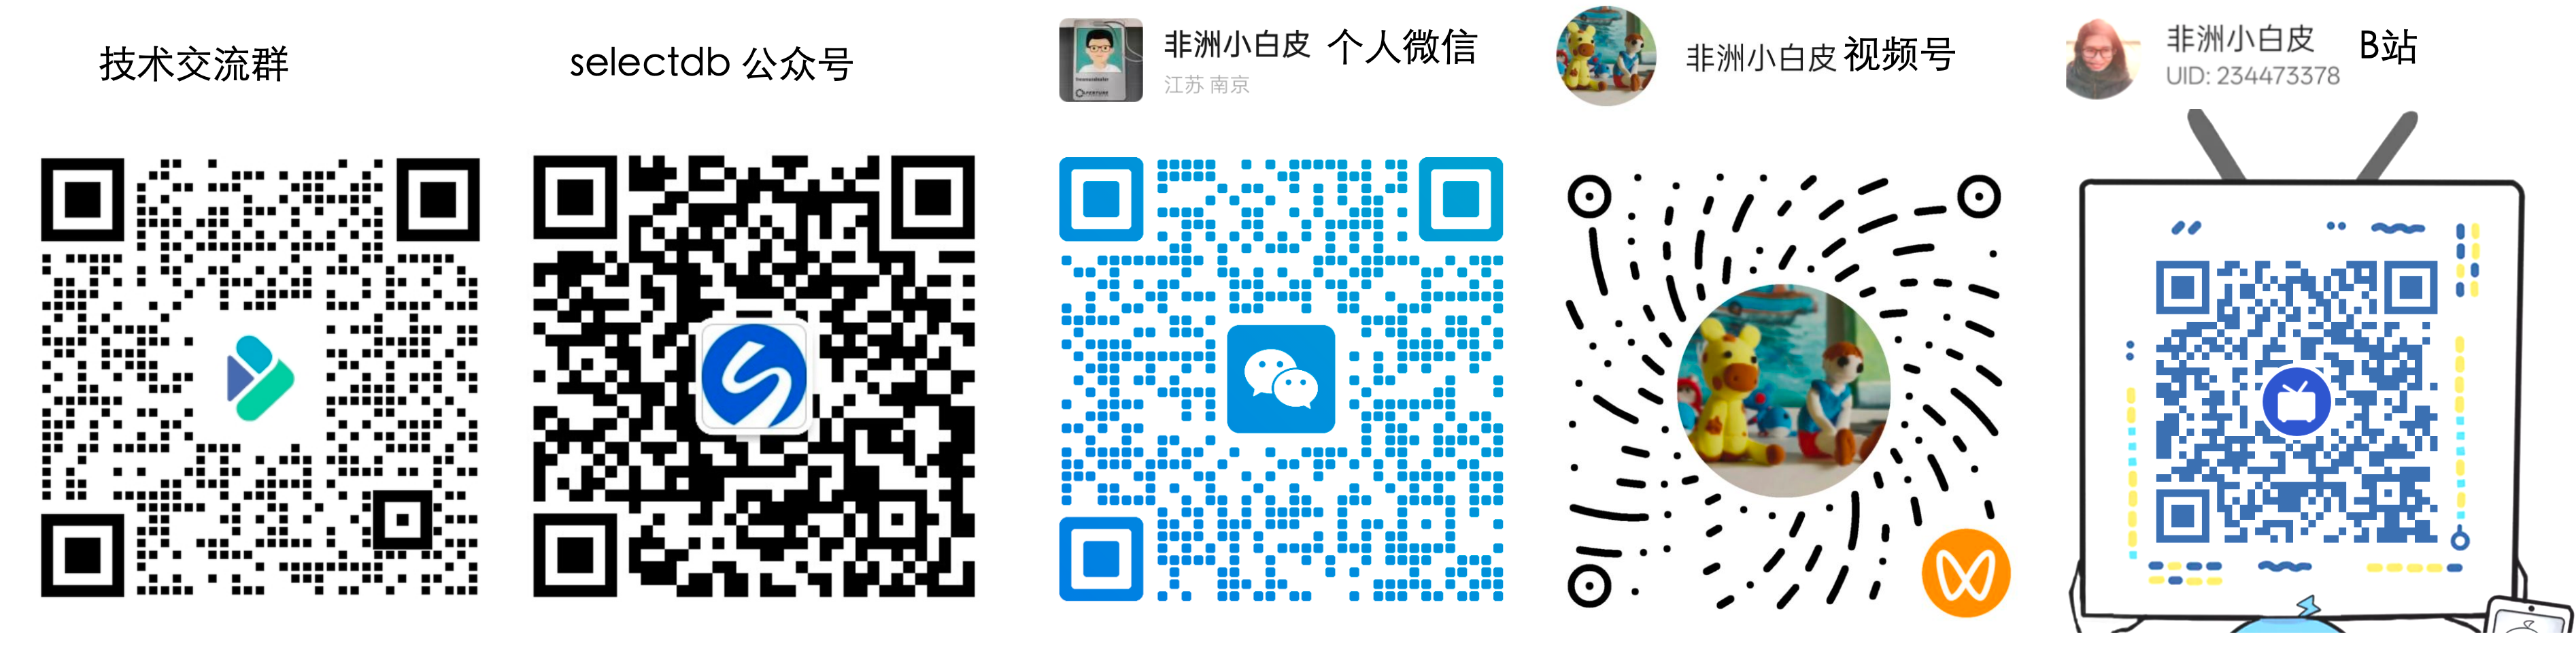